<>:84: SyntaxWarning: invalid escape sequence '\p'
<>:211: SyntaxWarning: invalid escape sequence '\p'
<>:84: SyntaxWarning: invalid escape sequence '\p'
<>:211: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_3274/3155697951.py:84: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Task 1.3: $V^\pi(s)$ for Evaluated Policy")
/tmp/ipykernel_3274/3155697951.py:211: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Task 3.3a: $V^\pi(s)$ across Policy Iteration Steps")


--- Task 1.1: MDP Setup Verification ---
Sum of P[High, Search]: 1.0
Sum of P[High, Wait]: 1.0
Sum of P[Low, Search]: 1.0
Sum of P[Low, Wait]: 1.0
Sum of P[Charging, Search]: 1.0
Sum of P[Charging, Wait]: 1.0

Expected Reward Array R:
 [[   4.     1. ]
 [   1.2    1. ]
 [-100.     0. ]]

--- Task 1.2: Evaluating specific policy ---
Policy Evaluation converged in 133 iterations.
V(High) = 18.1081
V(Low) = 10.0000
V(Charging) = 16.2973


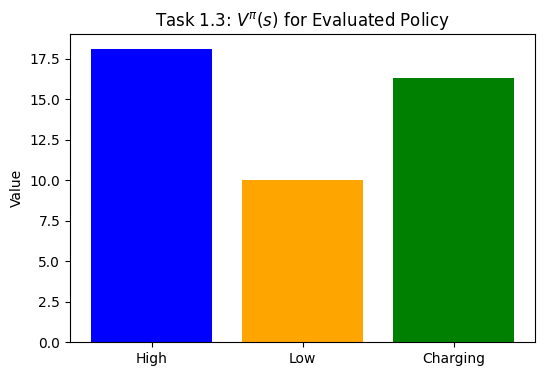


--- Task 2: Value Iteration ---

Value Iteration converged in 142 iterations.
Optimal Values:
V*(High) = 29.6438
V*(Low) = 25.8082
V*(Charging) = 26.6794

Optimal Policy:
pi*(High) = Search
pi*(Low) = Search
pi*(Charging) = Wait


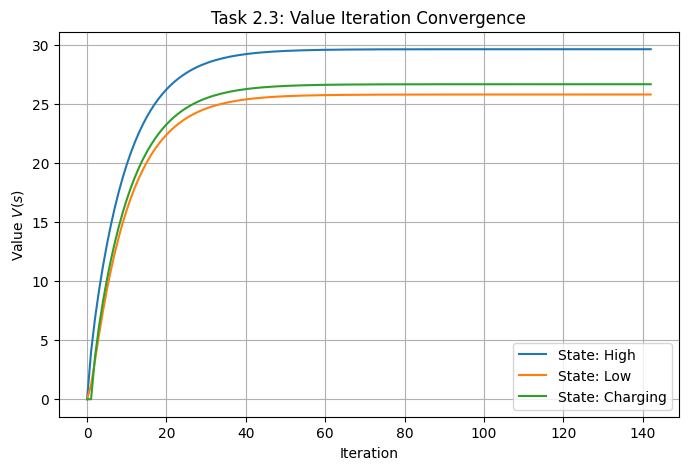


--- Task 3: Policy Iteration Loop ---
Policy Evaluation converged in 133 iterations.
Iteration 1: Policy = ['Wait', 'Wait', 'Wait'], V = [10. 10.  9.]
Policy Evaluation converged in 142 iterations.
Iteration 2: Policy = ['Search', 'Search', 'Wait'], V = [29.64 25.81 26.68]
Policy Iteration converged after 2 full loops.


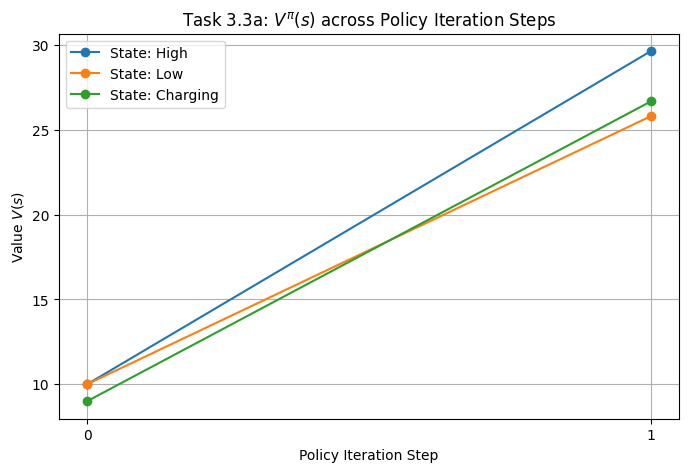

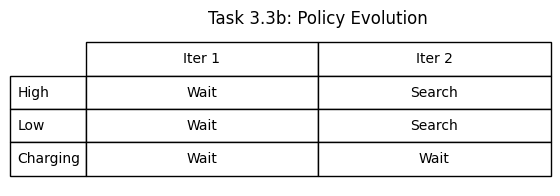

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Task 1.1: Build the MDP
# ==========================================
STATES = ['High', 'Low', 'Charging'] # Indices: 0, 1, 2
ACTIONS = ['Search', 'Wait']         # Indices: 0, 1
GAMMA = 0.9
THETA = 1e-6

# Initialize P: shape (states, actions, next_states) -> (3, 2, 3)
P = np.zeros((3, 2, 3))
# Initialize R: shape (states, actions) -> (3, 2)
# R[s,a] is the expected immediate reward: sum over s' of P(s'|s,a) * R(s,a,s')
R = np.zeros((3, 2))

# High (0)
P[0, 0, 0] = 0.7  # High -> Search -> High
P[0, 0, 1] = 0.3  # High -> Search -> Low
R[0, 0] = (0.7 * 4) + (0.3 * 4) # Expected reward = 4.0

P[0, 1, 0] = 1.0  # High -> Wait -> High
R[0, 1] = (1.0 * 1) # Expected reward = 1.0

# Low (1)
P[1, 0, 0] = 0.4  # Low -> Search -> High
P[1, 0, 1] = 0.6  # Low -> Search -> Low
R[1, 0] = (0.4 * -3) + (0.6 * 4) # Expected reward = 1.2

P[1, 1, 1] = 1.0  # Low -> Wait -> Low
R[1, 1] = (1.0 * 1) # Expected reward = 1.0

# Charging (2)
# Note: 'Search' is NOT allowed in Charging. We handle this by making 'Search'
# transition to 'Charging' with a huge penalty to deter the agent.
P[2, 0, 2] = 1.0
R[2, 0] = -100.0

P[2, 1, 0] = 1.0  # Charging -> Wait -> High
R[2, 1] = (1.0 * 0) # Expected reward = 0.0

print("--- Task 1.1: MDP Setup Verification ---")
for s in range(3):
    for a in range(2):
        print(f"Sum of P[{STATES[s]}, {ACTIONS[a]}]: {np.sum(P[s, a, :])}")
print("\nExpected Reward Array R:\n", R)


# ==========================================
# Task 1.2: Iterative Policy Evaluation
# ==========================================
def policy_evaluation(P, R, policy, gamma, theta):
    V = np.zeros(3)
    iterations = 0
    while True:
        delta = 0
        V_new = np.zeros(3)
        for s in range(3):
            a = policy[s]
            # Bellman expectation update
            expected_value = sum([P[s, a, s_prime] * V[s_prime] for s_prime in range(3)])
            V_new[s] = R[s, a] + gamma * expected_value
            delta = max(delta, abs(V_new[s] - V[s]))

        V = V_new
        iterations += 1
        if delta < theta:
            break

    print(f"Policy Evaluation converged in {iterations} iterations.")
    return V

print("\n--- Task 1.2: Evaluating specific policy ---")
# Policy: High -> Search (0), Low -> Wait (1), Charging -> Wait (1)
eval_policy = [0, 1, 1]
V_pi = policy_evaluation(P, R, eval_policy, GAMMA, THETA)
for i, s in enumerate(STATES):
    print(f"V({s}) = {V_pi[i]:.4f}")

# Task 1.3: Plot
plt.figure(figsize=(6, 4))
plt.bar(STATES, V_pi, color=['blue', 'orange', 'green'])
plt.title("Task 1.3: $V^\pi(s)$ for Evaluated Policy")
plt.ylabel("Value")
plt.show()


# ==========================================
# Task 2: Value Iteration
# ==========================================
def value_iteration(P, R, gamma, theta):
    V = np.zeros(3)
    history = []
    iterations = 0

    while True:
        history.append(V.copy())
        delta = 0
        V_new = np.zeros(3)

        for s in range(3):
            q_values = np.zeros(2)
            for a in range(2):
                expected_value = sum([P[s, a, s_prime] * V[s_prime] for s_prime in range(3)])
                q_values[a] = R[s, a] + gamma * expected_value

            V_new[s] = np.max(q_values)
            delta = max(delta, abs(V_new[s] - V[s]))

        V = V_new
        iterations += 1
        if delta < theta:
            history.append(V.copy())
            break

    print(f"\nValue Iteration converged in {iterations} iterations.")
    return V, history

def extract_policy(V_star, P, R, gamma):
    policy = np.zeros(3, dtype=int)
    for s in range(3):
        q_values = np.zeros(2)
        for a in range(2):
            expected_value = sum([P[s, a, s_prime] * V_star[s_prime] for s_prime in range(3)])
            q_values[a] = R[s, a] + gamma * expected_value
        policy[s] = np.argmax(q_values)

        # Enforce rule: Search NOT allowed in Charging
        if s == 2: policy[s] = 1

    return policy

print("\n--- Task 2: Value Iteration ---")
V_star_vi, vi_history = value_iteration(P, R, GAMMA, THETA)
optimal_policy_vi = extract_policy(V_star_vi, P, R, GAMMA)

print("Optimal Values:")
for i, s in enumerate(STATES):
    print(f"V*({s}) = {V_star_vi[i]:.4f}")

print("\nOptimal Policy:")
for i, s in enumerate(STATES):
    print(f"pi*({s}) = {ACTIONS[optimal_policy_vi[i]]}")

# Task 2.3: Plot Convergence
vi_history = np.array(vi_history)
plt.figure(figsize=(8, 5))
for i in range(3):
    plt.plot(vi_history[:, i], label=f'State: {STATES[i]}')
plt.title("Task 2.3: Value Iteration Convergence")
plt.xlabel("Iteration")
plt.ylabel("Value $V(s)$")
plt.legend()
plt.grid(True)
plt.show()


# ==========================================
# Task 3: Policy Iteration
# ==========================================
def policy_improvement(V, P, R, gamma, current_policy):
    new_policy = np.zeros(3, dtype=int)
    for s in range(3):
        q_values = np.zeros(2)
        for a in range(2):
            expected_value = sum([P[s, a, s_prime] * V[s_prime] for s_prime in range(3)])
            q_values[a] = R[s, a] + gamma * expected_value

        new_policy[s] = np.argmax(q_values)
        if s == 2: new_policy[s] = 1 # Force wait for charging state

    stable = np.array_equal(new_policy, current_policy)
    return new_policy, stable

def policy_iteration(P, R, gamma, theta):
    # Start from initial policy: all states take Wait
    policy = np.array([1, 1, 1])

    policy_history = []
    v_history = []
    iteration = 0

    print("\n--- Task 3: Policy Iteration Loop ---")
    while True:
        iteration += 1
        # Policy Evaluation
        V = policy_evaluation(P, R, policy, gamma, theta)

        policy_history.append(policy.copy())
        v_history.append(V.copy())

        print(f"Iteration {iteration}: Policy = {[ACTIONS[p] for p in policy]}, V = {np.round(V, 2)}")

        # Policy Improvement
        policy, stable = policy_improvement(V, P, R, gamma, policy)

        if stable:
            print(f"Policy Iteration converged after {iteration} full loops.")
            break

    return policy, V, policy_history, v_history

optimal_policy_pi, V_star_pi, pi_pol_history, pi_v_history = policy_iteration(P, R, GAMMA, THETA)

# Task 3.3: Plot Results
pi_v_history = np.array(pi_v_history)
plt.figure(figsize=(8, 5))
for i in range(3):
    plt.plot(pi_v_history[:, i], marker='o', label=f'State: {STATES[i]}')
plt.title("Task 3.3a: $V^\pi(s)$ across Policy Iteration Steps")
plt.xlabel("Policy Iteration Step")
plt.ylabel("Value $V(s)$")
plt.xticks(range(len(pi_v_history)))
plt.legend()
plt.grid(True)
plt.show()

# Task 3.3b: Heatmap Table
fig, ax = plt.subplots(figsize=(6, 2))
ax.axis('tight')
ax.axis('off')
table_data = []
for i, pol in enumerate(pi_pol_history):
    table_data.append([ACTIONS[a] for a in pol])
# Transpose to have states as rows and iterations as columns
table_data = np.array(table_data).T.tolist()

table = ax.table(cellText=table_data,
                 rowLabels=STATES,
                 colLabels=[f"Iter {i+1}" for i in range(len(pi_pol_history))],
                 loc='center', cellLoc='center')
table.scale(1, 2)
plt.title("Task 3.3b: Policy Evolution")
plt.show()